# Clustering and PCA Techniques

##  Learning Outcomes

After this video, you'll be able to:

<ul>
    <li>Prepare customer data for unsupervised learning</li>
    <li>Implement K-means clustering to identify customer segments</li>
    <li>Apply PCA to visualize high-dimensional data</li>
    <li>Evaluate clustering results for business insights</li>
</ul>

## Environment and Data Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load and preview data
df = pd.read_csv('insightlysoft_dataset.csv')
df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned,is_heavy_user
0,A0001,21,5.0,6,28.16,58,6.390714,0,5,1.51,89.98,8.42,Chicago,Female,0,1
1,A0002,13,5.0,6,18.70,33,0.792736,1,20,1.33,11.82,1.33,New York,Female,1,0
2,A0003,23,5.0,6,32.73,61,5.267689,0,2,0.48,31.07,6.60,Austin,Female,0,1
3,A0004,25,5.0,6,9.25,4,5.548030,0,34,2.04,77.84,5.75,Chicago,Male,1,1
4,A0005,16,18.0,24,29.08,99,-0.017153,0,4,1.92,54.32,0.31,Austin,Female,0,1


## Data Preparation

In [2]:
# Select numeric features
features = ['monthly_login_freq', 'avg_product_usage_hours', 
           'num_users', 'feature_adoption_score']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

## KMeans Clustering

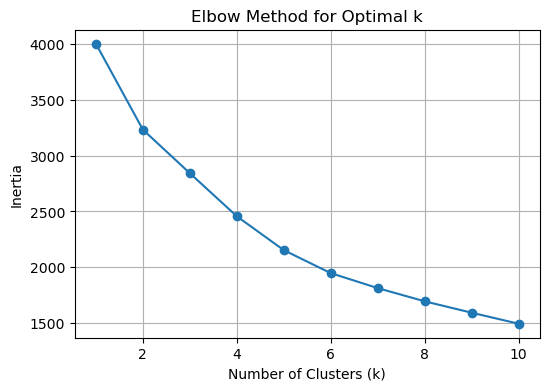

In [3]:
# Find optimal clusters using elbow method
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plotting elbow curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Apply clustering with optimal k
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

## PCA Implementation

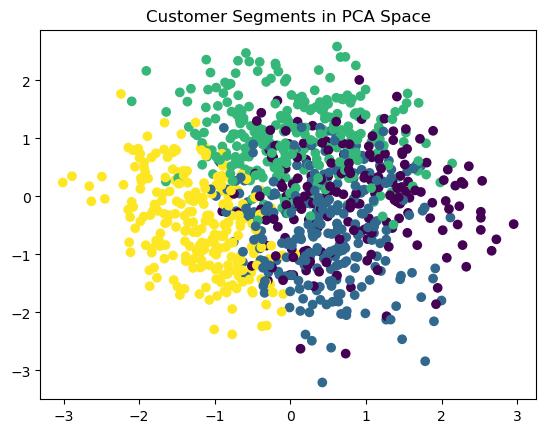

In [4]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title('Customer Segments in PCA Space')
plt.show()

## Cluster Analysis

In [5]:
# Calculate cluster profiles
cluster_profiles = df.groupby(clusters)[features].mean()
print("Cluster Profiles:")
print(cluster_profiles)

Cluster Profiles:
   monthly_login_freq  avg_product_usage_hours  num_users  \
0           21.383420                40.780466  52.274611   
1           20.763251                29.533604  78.155477   
2           18.678700                22.685307  48.682310   
3           19.052632                28.460405  24.473684   

   feature_adoption_score  
0               72.736943  
1               31.586572  
2               76.721444  
3               25.914656  


## Recap


In this video, we covered:

- Data preparation and scaling 

- K-means clustering implementation 

- PCA for visualization 

- Cluster analysis and interpretation

